In [1]:
# to make the refactoring easier

In [2]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.insert(0, "src")
# all imports here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS, GeocentricTrueEcliptic
from astroML.density_estimation import EmpiricalDistribution
from math import lgamma
import gc

from tqdm import tqdm

## ------------------------------------------------------------------------------- 

### All populations from s3m loaded in

In [4]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [5]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [6]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [7]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


## ------------------------------------------------------------------------------- 

### section to compute apparent magnitude for full population on the full sky

In [8]:
def compute_apparent_magnitude_for_population(
    df,
    obstime_str,
    scorer,
    chunk=100_000,
    show_progress=True,
):
    """
    Compute apparent magnitude for every object in the full population df
    at obstime_str, BEFORE any sky-position cut.
    """

    AU_KM = 149597870.7

    # propagate all rows in df
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # rotate ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    # Earth heliocentric state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    r_helio_vec = r_eq
    r_obs_vec = r_eq - (rE + r_tele)
    
    r_sun = np.linalg.norm(r_helio_vec, axis=1)
    Delta = np.linalg.norm(r_obs_vec, axis=1)
    
    if np.nanmedian(r_sun) > 1000:
        r_sun = r_sun / AU_KM
        Delta = Delta / AU_KM
    
    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    # HG phase function
    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    H = df["H"].to_numpy(dtype=float)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)
    return mag_app

In [9]:
def select_df_by_mag_bin(df, mag_app, mag_min=None, mag_max=None):
    """
    Select rows directly from the full population df using apparent magnitude.
    """
    sel = np.isfinite(mag_app)

    if mag_min is not None:
        sel &= (mag_app >= mag_min)

    if mag_max is not None:
        sel &= (mag_app < mag_max)

    df_sel = df.loc[sel].copy()
    mag_sel = mag_app[sel]

    return df_sel, mag_sel
    # df_sel here is magnitude filtered but whole sky

## ------------------------------------------------------------------------------- 

### helper functions
#### so mean_anomaly_deg_at_obstime and mean_longitude_deg_at_obstime are not doing anything for the cloner — they are purely for annotating visible_df with M_obs_deg and L_obs_deg columns. Those columns end up in visible_df and are available for diagnostics and plots (e.g. checking the phase distribution of the visible subset), but the cloner recomputes M_obs itself from scratch from t_p and a so it does not actually read those columns.

#### build_visible_subset_dataframe calls them to annotate the output dataframe.

In [10]:
def wrap360_deg(x):
    return np.mod(x, 360.0)

def mean_anomaly_deg_at_obstime(a_AU, tp_mjd, obstime_str):
    t_obs = Time(obstime_str, scale="tdb")
    a_AU = np.asarray(a_AU, dtype=float)
    tp_mjd = np.asarray(tp_mjd, dtype=float)
    a_km = a_AU * AU_km
    n_rad_s = np.sqrt(mu_sun / a_km**3)
    n_rad_day = n_rad_s * 86400.0
    M_rad = n_rad_day * (t_obs.mjd - tp_mjd)
    return wrap360_deg(np.rad2deg(M_rad))

def mean_longitude_deg_at_obstime(a_AU, node_deg, argperi_deg, tp_mjd, obstime_str):
    M_deg = mean_anomaly_deg_at_obstime(a_AU, tp_mjd, obstime_str)
    return wrap360_deg(node_deg + argperi_deg + M_deg)

### Sky patch cut and orbital phase

In [11]:
# currently passing df_sel so the mag filtered df not the whole population
def build_visible_subset_dataframe(
    df,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",   # "custom_ecliptic" or "antisun"
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    """
    Propagate the ORIGINAL dataframe to obstime_str, apply the sky cut,
    and return a dataframe of only the objects that survive.

    Adds:
        M_obs_deg
        L_obs_deg
        ra_deg
        dec_deg
        dra_deg_day
        ddec_deg_day
        vlam
        vbeta
        sky_sep_deg
    """
    t_obs = Time(obstime_str, scale="tdb")

    # original row indices so we can map mask -> dataframe rows
    orig_idx = np.arange(len(df), dtype=int)

    # orbital elements from dataframe
    a_AU = df["a"].to_numpy(dtype=float)
    e = df["e"].to_numpy(dtype=float)
    inc = df["i"].to_numpy(dtype=float)
    raan = df["node"].to_numpy(dtype=float)
    argp = df["argperi"].to_numpy(dtype=float)
    tp_mjd = df["t_p"].to_numpy(dtype=float)

    # heliocentric ecliptic state from existing pipeline
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x * vy - y * vx) / rho2
    ddec = (vz * rho2 - z * (x * vx + y * vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    orig_idx_good = orig_idx[good]

    ra_deg = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame=GCRS(obstime=t_obs))

    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sky_sep_deg = sc.separation(center_sc).deg
    m = sky_sep_deg <= max_sep_deg

    # selected rows in original dataframe
    sel_idx = orig_idx_good[m]
    out = df.iloc[sel_idx].copy().reset_index(drop=True)

    out["ra_deg"] = ra_deg[m]
    out["dec_deg"] = dec_deg[m]
    out["dra_deg_day"] = dra_deg_day[m]
    out["ddec_deg_day"] = ddec_deg_day[m]
    out["sky_sep_deg"] = sky_sep_deg[m]

    # ecliptic rates
    sc_with_rates = SkyCoord(
        ra=out["ra_deg"].to_numpy() * u.deg,
        dec=out["dec_deg"].to_numpy() * u.deg,
        distance=np.ones(len(out)) * u.au,
        pm_ra_cosdec=out["dra_deg_day"].to_numpy() * u.deg / u.day,
        pm_dec=out["ddec_deg_day"].to_numpy() * u.deg / u.day,
        radial_velocity=np.zeros(len(out)) * u.km / u.s,
        frame=GCRS(obstime=t_obs),
    )
    sc_ecl = sc_with_rates.transform_to(GeocentricTrueEcliptic(obstime=t_obs))
    out["vlam"] = sc_ecl.pm_lon_coslat.to(u.deg / u.day).value
    out["vbeta"] = sc_ecl.pm_lat.to(u.deg / u.day).value

    # phase like quantities at this obstime
    out["M_obs_deg"] = mean_anomaly_deg_at_obstime(
        out["a"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    out["L_obs_deg"] = mean_longitude_deg_at_obstime(
        out["a"].to_numpy(),
        out["node"].to_numpy(),
        out["argperi"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    return out

In [11]:
# lets see if this fixes bug
def build_visible_subset_dataframe(
    df,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    """
    Propagate the ORIGINAL dataframe to obstime_str, apply the sky cut,
    and return a dataframe of only the objects that survive.

    Adds:
        M_obs_deg
        L_obs_deg
        ra_deg
        dec_deg
        dra_deg_day
        ddec_deg_day
        vlam
        vbeta
        sky_sep_deg
    """
    t_obs = Time(obstime_str, scale="tdb")

    # original row indices so we can map mask -> dataframe rows
    orig_idx = np.arange(len(df), dtype=int)

    # orbital elements from dataframe
    a_AU = df["a"].to_numpy(dtype=float)
    e = df["e"].to_numpy(dtype=float)
    inc = df["i"].to_numpy(dtype=float)
    raan = df["node"].to_numpy(dtype=float)
    argp = df["argperi"].to_numpy(dtype=float)
    tp_mjd = df["t_p"].to_numpy(dtype=float)

    # heliocentric ecliptic state from existing pipeline
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and rates in equatorial frame
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x * x + y * y
    r2 = rho2 + z * z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x * vy - y * vx) / rho2
    ddec = (vz * rho2 - z * (x * vx + y * vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & (rho2 > 0) &
        np.isfinite(r2) & (r2 > 0) &
        np.isfinite(rho) & (rho > 0)
    )

    orig_idx_good = orig_idx[good]

    ra_deg = np.rad2deg(ra[good]) % 360.0
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs),
    )

    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sky_sep_deg = sc.separation(center_sc).deg
    m = sky_sep_deg <= max_sep_deg

    # selected rows in original dataframe
    sel_idx = orig_idx_good[m]
    out = df.iloc[sel_idx].copy().reset_index(drop=True)

    out["ra_deg"] = ra_deg[m]
    out["dec_deg"] = dec_deg[m]
    out["dra_deg_day"] = dra_deg_day[m]
    out["ddec_deg_day"] = ddec_deg_day[m]
    out["sky_sep_deg"] = sky_sep_deg[m]

    # selected relative state vectors in equatorial frame
    r_rel_sel = r_rel[good][m]
    v_rel_sel = v_rel[good][m]

    # rotate equatorial -> ecliptic
    x_ecl = r_rel_sel[:, 0]
    y_ecl = c * r_rel_sel[:, 1] + s * r_rel_sel[:, 2]
    z_ecl = -s * r_rel_sel[:, 1] + c * r_rel_sel[:, 2]

    vx_ecl = v_rel_sel[:, 0]
    vy_ecl = c * v_rel_sel[:, 1] + s * v_rel_sel[:, 2]
    vz_ecl = -s * v_rel_sel[:, 1] + c * v_rel_sel[:, 2]

    rho2_ecl = x_ecl * x_ecl + y_ecl * y_ecl
    r2_ecl = rho2_ecl + z_ecl * z_ecl
    rho_ecl = np.sqrt(rho2_ecl)

    lam = np.arctan2(y_ecl, x_ecl)
    beta = np.arctan2(z_ecl, rho_ecl)

    dlam = (x_ecl * vy_ecl - y_ecl * vx_ecl) / rho2_ecl
    dbeta = (vz_ecl * rho2_ecl - z_ecl * (x_ecl * vx_ecl + y_ecl * vy_ecl)) / (r2_ecl * rho_ecl)

    out["lam_deg"] = np.rad2deg(lam) % 360.0
    out["beta_deg"] = np.rad2deg(beta)
    out["vlam"] = np.rad2deg(dlam) * 86400.0
    out["vbeta"] = np.rad2deg(dbeta) * 86400.0

    # phase-like quantities at this obstime
    out["M_obs_deg"] = mean_anomaly_deg_at_obstime(
        out["a"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    out["L_obs_deg"] = mean_longitude_deg_at_obstime(
        out["a"].to_numpy(),
        out["node"].to_numpy(),
        out["argperi"].to_numpy(),
        out["t_p"].to_numpy(),
        obstime_str,
    )

    return out

### cloning w mean anomaly randomisation using astroml 

In [12]:
# always pass df_sel (for mag cut) or out (the output of build_visible_subset_dataframe) not the full raw pop. 
def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """
    Clone each orbit clone_factor times using an astroML-style empirical
    distribution of mean anomaly M(obstime) measured from the input subset.

    The sampled mean anomalies are restricted to the min/max range of the
    subset after circular unwrapping.

    Returns
    -------
    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_out
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    # always use a directly from dataset
    a_AU = df["a"].to_numpy(dtype=np.float64)
    e = df["e"].to_numpy(dtype=np.float32)
    inc = df["i"].to_numpy(dtype=np.float32)
    raan = df["node"].to_numpy(dtype=np.float32)
    argp = df["argperi"].to_numpy(dtype=np.float32)
    tp = df["t_p"].to_numpy(dtype=np.float64)

    # repeat fixed elements
    a_rep = np.repeat(a_AU, clone_factor).astype(np.float64)
    e_rep = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_AU * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km ** 3))
    n_rad_day = n_rad_s * 86400.0

    # observed/catalog mean anomaly at obstime
    M_obs = np.mod((t_obs.mjd - tp) * n_rad_day, 2.0 * np.pi)

    # shift the circular distribution so it is not split at 0 / 2pi
    mean_angle = np.angle(np.mean(np.exp(1j * M_obs)))
    M_shift = np.mod(M_obs - mean_angle, 2.0 * np.pi)

    # subset support in shifted coordinates
    M_min = M_shift.min()
    M_max = M_shift.max()

    # empirical clone in shifted coordinates
    # astroML expects shape (N, D), so use [:, None]
    M_shift_clone = EmpiricalDistribution(M_shift).rvs(len(a_rep))

    # enforce sampled support to stay inside subset min/max
    M_shift_clone = np.clip(M_shift_clone, M_min, M_max)

    # wrap back to [0, 2pi)
    M_clone = np.mod(M_shift_clone + mean_angle, 2.0 * np.pi)

    # repeat mean motion for cloned sample
    n_rep = np.repeat(n_rad_day, clone_factor)

    # choose t_p so that M(obstime) = M_clone
    tp_out = (t_obs.mjd - (M_clone / n_rep)).astype(np.float32)

    return (
        a_rep.astype(np.float32),
        e_rep,
        inc_rep,
        raan_rep,
        argp_rep,
        tp_out,
    )

###  4. propagation post cloning 

In [14]:
# using the version created in cloned_ecliptic_scan_magcut.ipynb for the H vs D plots
def elements_to_vlam_vbeta_d_h(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    H_vals,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",   # "custom_ecliptic" or "antisun"
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    """
    Convert orbital elements -> visible vlam, vbeta, d_au, H
    using the same sky-cut logic as elements_to_vlam_vbeta().

    H_vals must be the same length as a_AU/e/inc/raan/argp/tp_mjd.
    """
    t_obs = Time(obstime_str, scale="tdb")
    AU_KM = AU_km

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # distance from observer
    d_raw = np.linalg.norm(r_rel, axis=1)
    if np.nanmedian(d_raw) > 1000:
        d_au_all = d_raw / AU_KM
    else:
        d_au_all = d_raw.copy()

    # RA/Dec and rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    d_au_good = d_au_all[good]
    H_good = np.asarray(H_vals, dtype=float)[good]

    # object sky coords in GCRS
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    # choose center of sky cut
    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )

    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))

    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    ra_deg = ra_deg[m]
    dec_deg = dec_deg[m]
    dra_deg_day = dra_deg_day[m]
    ddec_deg_day = ddec_deg_day[m]
    d_au_vis = d_au_good[m]
    H_vis = H_good[m]

    # RA/Dec rates -> ecliptic rates (bypass nsc due to astropy differential bug)
    sc_with_rates = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        distance=np.ones(len(ra_deg)) * u.au,
        pm_ra_cosdec=dra_deg_day * u.deg / u.day,
        pm_dec=ddec_deg_day * u.deg / u.day,
        radial_velocity=np.zeros(len(ra_deg)) * u.km / u.s,
        frame=GCRS(obstime=t_obs),
    )
    sc_ecl = sc_with_rates.transform_to(GeocentricTrueEcliptic(obstime=t_obs))
    vlam = sc_ecl.pm_lon_coslat.to(u.deg / u.day).value
    vbeta = sc_ecl.pm_lat.to(u.deg / u.day).value

    finite = np.isfinite(vlam) & np.isfinite(vbeta) & np.isfinite(d_au_vis) & np.isfinite(H_vis)

    vlam = vlam[finite].astype(np.float32)
    vbeta = vbeta[finite].astype(np.float32)
    d_au_vis = d_au_vis[finite].astype(np.float32)
    H_vis = H_vis[finite].astype(np.float32)

    return vlam, vbeta, d_au_vis, H_vis

In [13]:
def elements_to_vlam_vbeta_d_h(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    H_vals,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    """
    Convert orbital elements -> visible vlam, vbeta, d_au, H
    using the same sky-cut logic as build_visible_subset_dataframe.
    Bypasses astropy frame transforms entirely for rate conversion.

    H_vals must be the same length as a_AU/e/inc/raan/argp/tp_mjd.
    """
    t_obs = Time(obstime_str, scale="tdb")
    AU_KM = AU_km

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial rotation matrix
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors (equatorial)
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # distance from observer
    d_raw = np.linalg.norm(r_rel, axis=1)
    if np.nanmedian(d_raw) > 1000:
        d_au_all = d_raw / AU_KM
    else:
        d_au_all = d_raw.copy()

    # RA/Dec in equatorial (for sky-cut only)
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg  = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])

    d_au_good = d_au_all[good]
    H_good    = np.asarray(H_vals, dtype=float)[good]

    # sky-patch cut via angular separation in GCRS
    sc = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame=GCRS(obstime=t_obs))

    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    d_au_vis = d_au_good[m]
    H_vis    = H_good[m]

    # rotate equatorial -> ecliptic directly (no astropy frame transform)
    # uses same rotation matrix already computed above
    r_rel_vis = r_rel[good][m]
    v_rel_vis = v_rel[good][m]

    x_ecl  =  r_rel_vis[:, 0]
    y_ecl  =  c * r_rel_vis[:, 1] + s * r_rel_vis[:, 2]
    z_ecl  = -s * r_rel_vis[:, 1] + c * r_rel_vis[:, 2]

    vx_ecl =  v_rel_vis[:, 0]
    vy_ecl =  c * v_rel_vis[:, 1] + s * v_rel_vis[:, 2]
    vz_ecl = -s * v_rel_vis[:, 1] + c * v_rel_vis[:, 2]

    rho2_ecl = x_ecl * x_ecl + y_ecl * y_ecl
    r2_ecl   = rho2_ecl + z_ecl * z_ecl
    rho_ecl  = np.sqrt(rho2_ecl)

    dlam  = (x_ecl * vy_ecl - y_ecl * vx_ecl) / rho2_ecl
    dbeta = (vz_ecl * rho2_ecl - z_ecl * (x_ecl * vx_ecl + y_ecl * vy_ecl)) / (r2_ecl * rho_ecl)

    vlam  = (np.rad2deg(dlam)  * 86400.0).astype(np.float32)
    vbeta = (np.rad2deg(dbeta) * 86400.0).astype(np.float32)

    finite = (
        np.isfinite(vlam) & np.isfinite(vbeta) &
        np.isfinite(d_au_vis) & np.isfinite(H_vis)
    )

    return (
        vlam[finite],
        vbeta[finite],
        d_au_vis[finite].astype(np.float32),
        H_vis[finite].astype(np.float32),
    )

In [14]:
#Similar to above but used for the ecliptic-strip scan workflow (scanning across ecliptic longitude centers rather than a single patch).
# Returns additional quantities needed for the strip plots.

def elements_to_eclipticstrip_quantities(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x * vy - y * vx) / rho2
    ddec = (vz * rho2 - z * (x * vx + y * vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame=GCRS(obstime=t_obs))

    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    ra_deg = ra_deg[m]
    dec_deg = dec_deg[m]
    dra_deg_day = dra_deg_day[m]
    ddec_deg_day = ddec_deg_day[m]

    sc_sel = SkyCoord(ra=ra_deg * u.deg, dec=dec_deg * u.deg, frame=GCRS(obstime=t_obs))
    ecl = sc_sel.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

    lam_deg = (ecl.lon.to_value(u.deg) % 360.0).astype(np.float32)
    beta_deg = ecl.lat.to_value(u.deg).astype(np.float32)

    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg,
        dec_deg,
        dra_deg_day,
        ddec_deg_day,
        obstime_str,
    )

    vlam = np.asarray(vlam, dtype=np.float32)
    vbeta = np.asarray(vbeta, dtype=np.float32)

    finite = (
        np.isfinite(lam_deg) &
        np.isfinite(beta_deg) &
        np.isfinite(vlam) &
        np.isfinite(vbeta)
    )

    return {
        "lam_deg": lam_deg[finite],
        "beta_deg": beta_deg[finite],
        "vlam": vlam[finite],
        "vbeta": vbeta[finite],
    }

### global variable BUT for cloning because this pipeline was not complicated enough already

In [15]:
# --- Global variables ---
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")
max_sep_deg = 30.0
AU_km = 149_597_870.7
mu_sun = 1.32712440018e11

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)

# --- Grid setup (density map) ---
from scipy.spatial import cKDTree

grid_step = 0.055   # change to 0.1 for fast tests or 0.01 for og value
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")
grid_points = np.column_stack((X0.ravel(), Y0.ravel()))

# --- Density estimator tuning ---
k_map = 10
n_d0_grid_map = 400

Nsample = None 
bins = 100

In [16]:
print(np.column_stack)
print(type(np.column_stack))
print(callable(np.column_stack))

<function column_stack at 0x7af6a0b80360>
<class 'numpy._ArrayFunctionDispatcher'>
True


### 5. Bayesian Density Estimation

### Compute the unnormalised log-posterior over the local spacing d₀ given k sorted nearest-neighbour distances. Implements the 2D Appendix B estimator.

In [17]:
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp

### Normalise a log-posterior sampled on a grid (trapezoid rule, log-shift for stability).

In [18]:
# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


### Query a cKDTree for the k nearest neighbours of a single evaluation point. Helper for the density estimator.

In [19]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

### Full posterior density estimate at a single grid point. Builds a d₀ grid, evaluates the posterior, returns posterior-mean density ⟨n₀⟩. Optional return_diagnostics=True for debugging.

In [20]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

### Loop over all grid points and call the single-point estimator. This is the main entry for producing a full density map. Build a cKDTree from the cloned (vlam, vbeta) points first.



In [21]:
# Evaluate full-posterior density on the whole grid

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

### Typical usage after cloning:
#### pts_clone = np.column_stack([vlam_clone, vbeta_clone])
#### tree_clone = cKDTree(pts_clone)

#### density_flat = evaluate_density_map_full_posterior_2d(
####    tree_clone, grid_points, k=k_map, n_d0_grid=n_d0_grid_map
#### )
#### density_map = density_flat.reshape(X0.shape)
#### density_downweighted = density_map / clone_factor


## Functions for plots etc. 

#### Loop over all populations in clone_sources, clone with the old uniform-M method (replace the inner call to use the fixed function), compute vlam/vbeta, build density maps, downweight. Returns clone_overlay, clone_density_maps, clone_density_maps_downweighted.

In [22]:
def build_cloned_maps_for_center(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] Cloning {pop_name} with factor {f}...")

        # sky-patch cut first so cloner sees only visible phase arc
        visible_df = build_visible_subset_dataframe(
            df,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print("  visible after sky cut:", len(visible_df))

        if len(visible_df) == 0:
            empty_map = np.zeros_like(X0, dtype=float)
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
            clone_density_maps[pop_name] = empty_map
            clone_density_maps_downweighted[pop_name] = empty_map
            continue

        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
            visible_df, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        H_rep = np.repeat(visible_df["H"].to_numpy(dtype=np.float32), f)

        vlam_clone, vbeta_clone, d_au_clone, H_clone = elements_to_vlam_vbeta_d_h(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            H_vals=H_rep,
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print(f"  final cloned visible points: {len(vlam_clone)}")

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new, H_rep
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        if n_overlay > 0:
            idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
            clone_overlay[pop_name] = {
                "vlam": vlam_clone[idx_overlay].copy(),
                "vbeta": vbeta_clone[idx_overlay].copy(),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
        else:
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        n_visible = len(pts_clone)

        if n_visible < 2:
            print(f"  too few visible points ({n_visible}) to build density map; returning zeros.")
            density_clone_map = np.zeros_like(X0, dtype=float)
            density_downweighted_map = np.zeros_like(X0, dtype=float)

        else:
            k_eff = min(k_map, n_visible - 1)

            if k_eff < 2:
                print(f"  too few visible points ({n_visible}) for stable kNN density; returning zeros.")
                density_clone_map = np.zeros_like(X0, dtype=float)
                density_downweighted_map = np.zeros_like(X0, dtype=float)

            else:
                print(f"  building density map with k_eff = {k_eff} (n_visible = {n_visible})")

                tree_clone = cKDTree(pts_clone)

                density_clone_flat = evaluate_density_map_full_posterior_2d(
                    tree_clone,
                    grid_points,
                    k=k_eff,
                    n_d0_grid=n_d0_grid_map,
                    show_progress=True,
                )

                density_clone_map = density_clone_flat.reshape(X0.shape)
                density_downweighted_map = density_clone_map / f

                del tree_clone, density_clone_flat

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, d_au_clone, H_clone, pts_clone
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

### Same as above but adds a magnitude pre-filter step: calls compute_apparent_magnitude_for_population + select_df_by_mag_bin before cloning. Also stores full_visible cloned points (vlam, vbeta, d_au, H) for science plots.



In [23]:
def clone_population_uniform_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """Old-style cloner: uniform random M over [0, 2pi). Use for full-population cloning."""
    if rng is None:
        rng = np.random.default_rng(0)
    t_obs = Time(obstime_str, scale="tdb")
    a_AU  = df["a"].to_numpy(dtype=np.float32)
    e     = df["e"].to_numpy(dtype=np.float32)
    inc   = df["i"].to_numpy(dtype=np.float32)
    raan  = df["node"].to_numpy(dtype=np.float32)
    argp  = df["argperi"].to_numpy(dtype=np.float32)
    a_rep    = np.repeat(a_AU, clone_factor).astype(np.float32)
    e_rep    = np.repeat(e,    clone_factor).astype(np.float32)
    inc_rep  = np.repeat(inc,  clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)
    a_km = a_rep.astype(np.float64) * AU_km
    n_rad_s   = np.sqrt(mu_sun / (a_km**3))
    n_rad_day = n_rad_s * 86400.0
    M_rand = rng.uniform(0.0, 2.0 * np.pi, size=len(a_rep)).astype(np.float64)
    tp_new = (t_obs.mjd - (M_rand / n_rad_day)).astype(np.float32)
    return a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new

In [24]:
def build_cloned_maps_for_center_magbin(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
    mag_min=None,
    mag_max=None,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}
    magcut_counts = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] {pop_name} with mag cut {mag_min} to {mag_max}...")

        mag_app = compute_apparent_magnitude_for_population(
            df=df,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            chunk=100_000,
            show_progress=True,
        )

        df_sel, mag_app_cut = select_df_by_mag_bin(
            df=df,
            mag_app=mag_app,
            mag_min=mag_min,
            mag_max=mag_max,
        )

        magcut_counts[pop_name] = len(df_sel)
        print("  objects passing mag cut:", len(df_sel))

        if len(df_sel) == 0:
            empty_map = np.zeros_like(X0, dtype=float)
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
            clone_density_maps[pop_name] = empty_map
            clone_density_maps_downweighted[pop_name] = empty_map
            continue

        # clone from full mag-filtered population with uniform phase
        # (not from visible subset — uniform cloning lets the sky cut
        #  naturally select from all orbit families in the patch)
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
            df_sel, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        H_rep = np.repeat(df_sel["H"].to_numpy(dtype=np.float32), f)

        vlam_clone, vbeta_clone, d_au_clone, H_clone = elements_to_vlam_vbeta_d_h(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            H_vals=H_rep,
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print("  final cloned visible points:", len(vlam_clone))

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new, H_rep
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        if n_overlay > 0:
            idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
            clone_overlay[pop_name] = {
                "vlam": vlam_clone[idx_overlay].copy(),
                "vbeta": vbeta_clone[idx_overlay].copy(),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }
        else:
            clone_overlay[pop_name] = {
                "vlam": np.array([]),
                "vbeta": np.array([]),
                "scatter_size": info["scatter_size"],
                "scatter_alpha": info["scatter_alpha"],
            }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        n_visible = len(pts_clone)

        if n_visible < 2:
            print(f"  too few visible points ({n_visible}) to build density map; returning zeros.")
            density_clone_map = np.zeros_like(X0, dtype=float)
            density_downweighted_map = np.zeros_like(X0, dtype=float)

        else:
            k_eff = min(k_map, n_visible - 1)

            if k_eff < 2:
                print(f"  too few visible points ({n_visible}) for stable kNN density; returning zeros.")
                density_clone_map = np.zeros_like(X0, dtype=float)
                density_downweighted_map = np.zeros_like(X0, dtype=float)

            else:
                print(f"  building density map with k_eff = {k_eff} (n_visible = {n_visible})")

                tree_clone = cKDTree(pts_clone)

                density_clone_flat = evaluate_density_map_full_posterior_2d(
                    tree_clone,
                    grid_points,
                    k=k_eff,
                    n_d0_grid=n_d0_grid_map,
                    show_progress=True,
                )

                density_clone_map = density_clone_flat.reshape(X0.shape)
                density_downweighted_map = density_clone_map / f

                del tree_clone, density_clone_flat

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, d_au_clone, H_clone, pts_clone
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "mag_min": mag_min,
        "mag_max": mag_max,
        "magcut_counts": magcut_counts,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

In [25]:
# for reference when calling select_df_by_mag_bin() use 
#df_sel, mag_app_cut = select_df_by_mag_bin(
#    df=df,
#    mag_app=mag_app,
#    mag_min=mag_min,
#    mag_max=mag_max,
#)
# and for build_visible_subset_dataframe
# visible_df = build_visible_subset_dataframe(
#    df_sel,   # <-- pass df_sel here, not df
#    ...
#)
# and
#a_rep, ... = clone_population_random_mean_anomaly(
#    visible_df,   # <-- pass visible_df here, not df_sel
#    ...
#)

### Propagate the raw (uncloned) full population, apply the sky-patch cut, compute vlam, vbeta, d_au, H, and mag_app for the survivors. Used for raw-population scatter plots and diagnostics that do not involve cloning.

In [26]:
def get_raw_patch_selected_sample(
    df,
    scorer,
    obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=20.0,
    chunk=100_000,
    show_progress=True,
):
    """
    Return raw population sample restricted to the selected sky patch, with:
      vlam, vbeta, d_au, H, mag_app
    """

    t_obs = Time(obstime_str, scale="tdb")

    # propagate to heliocentric ecliptic state
    r_ecl, v_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=df["a"].to_numpy(dtype=float),
        e=df["e"].to_numpy(dtype=float),
        inc_deg=df["i"].to_numpy(dtype=float),
        raan_deg=df["node"].to_numpy(dtype=float),
        argp_deg=df["argperi"].to_numpy(dtype=float),
        tp_mjd=df["t_p"].to_numpy(dtype=float),
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_eq = np.column_stack([
        r_ecl[:, 0],
        c * r_ecl[:, 1] - s * r_ecl[:, 2],
        s * r_ecl[:, 1] + c * r_ecl[:, 2],
    ])

    v_eq = np.column_stack([
        v_ecl[:, 0],
        c * v_ecl[:, 1] - s * v_ecl[:, 2],
        s * v_ecl[:, 1] + c * v_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative state
    r_rel = r_eq - (rE + r_tele)
    v_rel = v_eq - vE

    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2 = rho2 + z*z
    rho = np.sqrt(rho2)

    ra = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    # sky-patch selection in sky position
    ra_deg = np.rad2deg(ra[good]) % 360.0
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day = np.rad2deg(dra[good]) * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    center_ecl = SkyCoord(
        lon=center_lon_deg * u.deg,
        lat=center_lat_deg * u.deg,
        distance=1.0 * u.AU,
        frame=GeocentricTrueEcliptic(obstime=t_obs),
    )
    center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    good_idx = np.flatnonzero(good)
    patch_idx = good_idx[m]

    # vlam, vbeta for patch sample
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg[m],
        dec_deg[m],
        dra_deg_day[m],
        ddec_deg_day[m],
        obstime_str,
    )

    # distances and H for patch sample
    AU_KM = 149597870.7

    r_obs_vec = r_eq[patch_idx] - (rE + r_tele)
    d_au = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    H = df["H"].to_numpy(dtype=float)[patch_idx]

    # apparent magnitude for patch sample only
    r_helio_vec = r_eq[patch_idx]
    r_sun = np.linalg.norm(r_helio_vec, axis=1) / AU_KM
    Delta = np.linalg.norm(r_obs_vec, axis=1) / AU_KM

    u_sun = -r_helio_vec / np.linalg.norm(r_helio_vec, axis=1, keepdims=True)
    u_obs = -r_obs_vec / np.linalg.norm(r_obs_vec, axis=1, keepdims=True)

    cos_alpha = np.sum(u_sun * u_obs, axis=1)
    cos_alpha = np.clip(cos_alpha, -1.0, 1.0)
    alpha = np.arccos(cos_alpha)

    G = 0.15
    A1, A2, B1, B2 = 3.33, 1.87, 0.63, 1.22
    phi1 = np.exp(-A1 * np.tan(0.5 * alpha)**B1)
    phi2 = np.exp(-A2 * np.tan(0.5 * alpha)**B2)
    Phi = (1 - G) * phi1 + G * phi2
    Phi = np.maximum(Phi, 1e-30)

    mag_app = H + 5.0 * np.log10(r_sun * Delta) - 2.5 * np.log10(Phi)

    finite = (
        np.isfinite(vlam) &
        np.isfinite(vbeta) &
        np.isfinite(d_au) &
        np.isfinite(H) &
        np.isfinite(mag_app)
    )

    return {
        "vlam": np.asarray(vlam)[finite],
        "vbeta": np.asarray(vbeta)[finite],
        "d_au": d_au[finite],
        "H": H[finite],
        "mag_app": mag_app[finite],
    }

### extra keys (phase_col, phase_mode, jitter_deg) are only used by clone_visible_subset_by_phase, not by clone_population_random_mean_anomaly so remain unused till switch over

In [27]:
clone_sources = {
    "MBA": {
        "df": s3m,
        "scorer": scorer_mba_s3m,
        "clone_factor": 1,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 1.0,
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "df": neo,
        "scorer": scorer_neo_s3m,
        "clone_factor": 10,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 1.0,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "df": tno,
        "scorer": scorer_tno_s3m,
        "clone_factor": 10,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 1.0,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "df": trojan,
        "scorer": scorer_tjn_s3m,
        "clone_factor": 10,
        "phase_col": "M_obs_deg",
        "phase_mode": "empirical",
        "jitter_deg": 0.5,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

### magnitude bins

In [28]:
mag_bins = [
    {"label": "14_16", "mag_min": 14.0, "mag_max": 16.0},
    {"label": "16_18", "mag_min": 16.0, "mag_max": 18.0},
    {"label": "18_20", "mag_min": 18.0, "mag_max": 20.0},
    {"label": "mag20", "mag_min": 20.0, "mag_max": 21.0},
    {"label": "mag21", "mag_min": 21.0, "mag_max": 22.0},
    {"label": "mag22", "mag_min": 22.0, "mag_max": 23.0},
    {"label": "mag23", "mag_min": 23.0, "mag_max": 24.0},
    {"label": "mag24+", "mag_min": 24.0, "mag_max": 26.0},
]

rng = np.random.default_rng(42)
overlay_max = 200_000

In [29]:
# check for any list-type values in 'a' column of s3m
print(type(s3m["a"].iloc[0]))
print(s3m["a"].dtype)
print(s3m.dtypes)

<class 'numpy.float64'>
float64
OID          object
FORMAT       object
q           float64
e           float64
i           float64
node        float64
argperi     float64
t_p         float64
H           float64
t_0         float64
INDEX         int64
N_PAR         int64
MOID          int64
COMPCODE     object
a           float64
dtype: object


In [30]:
allpop_magbin_results = {}

for mbin in mag_bins:
    print("\n" + "="*80)
    print("Running all populations for mag bin:", mbin["label"])

    allpop_magbin_results[mbin["label"]] = build_cloned_maps_for_center_magbin(
        center_lon_deg=180.0,
        center_lat_deg=0.0,
        center_label="lon180_lat0",
        clone_sources=clone_sources,
        obstime_str=obstime_str,
        max_sep_deg=max_sep_deg,
        rng=rng,
        overlay_max=overlay_max,
        grid_points=grid_points,
        X0=X0,
        k_map=k_map,
        n_d0_grid_map=n_d0_grid_map,
        mag_min=mbin["mag_min"],
        mag_max=mbin["mag_max"],
    )


Running all populations for mag bin: 14_16

[lon180_lat0] MBA with mag cut 14.0 to 16.0...


Propagate with newton: 100%|██████████| 139/139 [00:09<00:00, 14.34it/s]


  objects passing mag cut: 1256
  cloned orbit count: 1256


Propagate with newton: 100%|██████████| 1/1 [00:00<00:00, 771.15it/s]

  final cloned visible points: 133


...

  objects passing mag cut: 106611
  cloned orbit count: 1066110


Propagate with newton: 100%|██████████| 11/11 [00:00<00:00, 16.18it/s]


  final cloned visible points: 131592
  building density map with k_eff = 10 (n_visible = 131592)


Evaluating density map: 100%|██████████| 961/961 [00:14<00:00, 66.14it/s]


Trojans done.
  raw cloned max density   : 55039608.66301152
  downweighted max density : 5503960.866301152


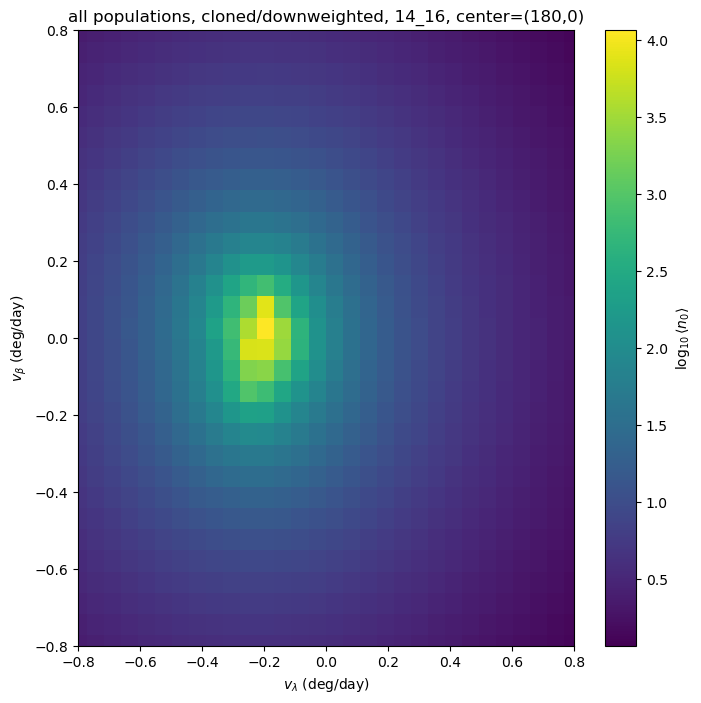

In [48]:
label = "14_16"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

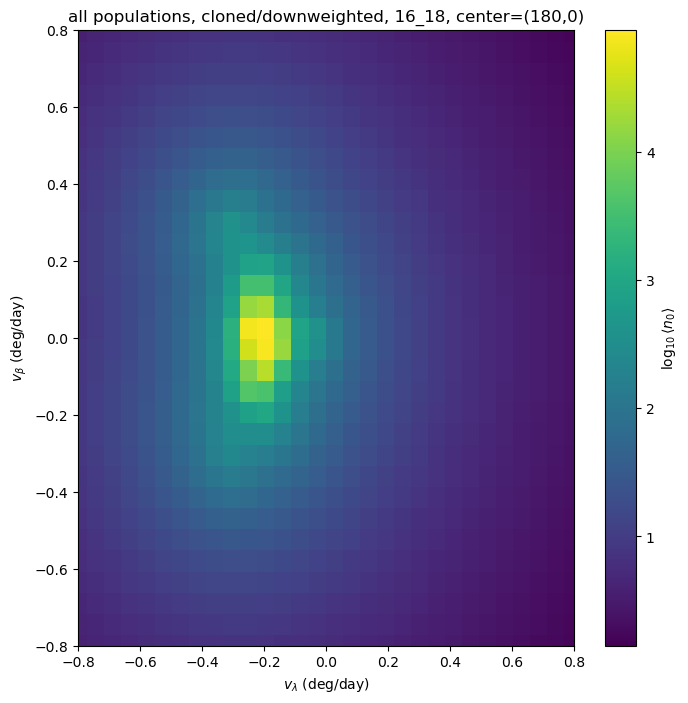

In [32]:
label = "16_18"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

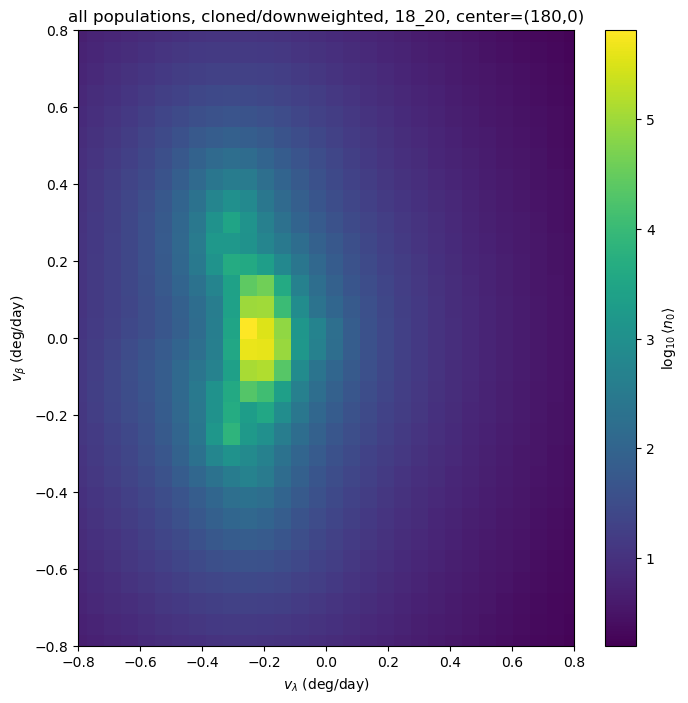

In [33]:
label = "18_20"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

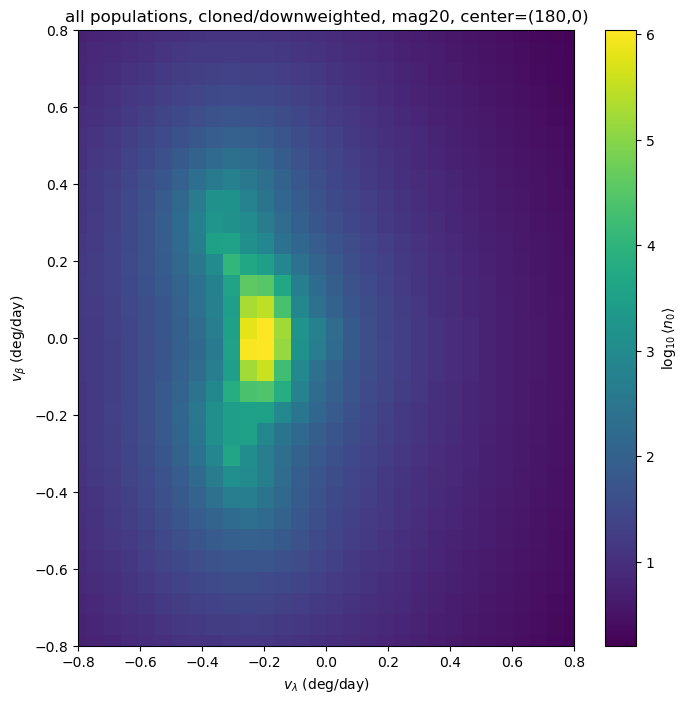

In [34]:
label = "mag20"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

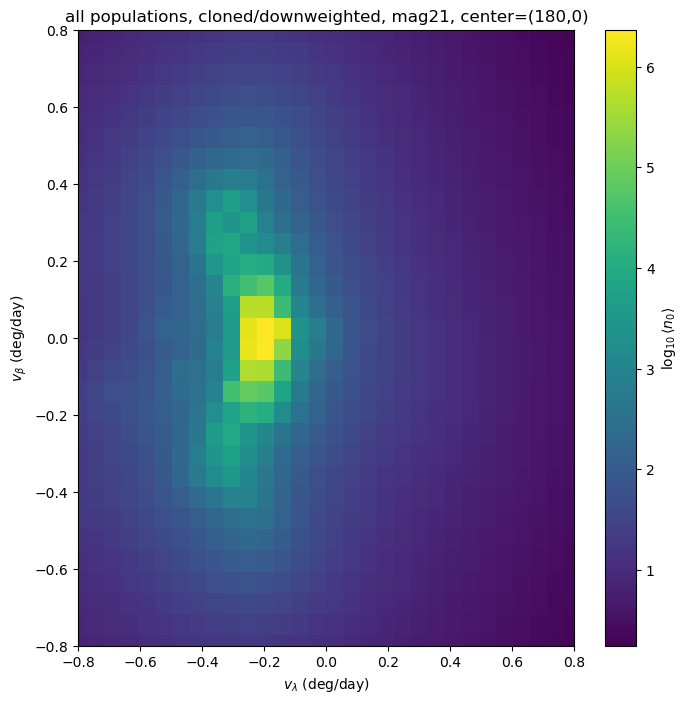

In [35]:
label = "mag21"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

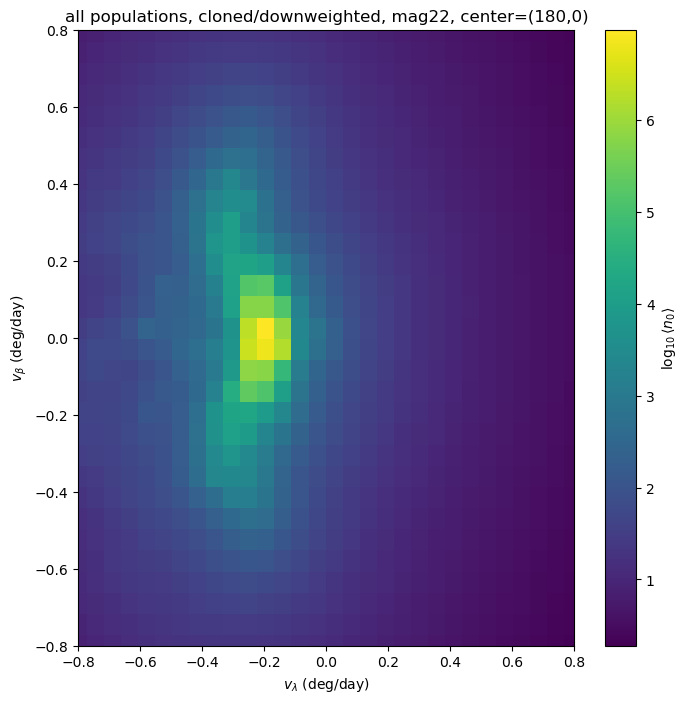

In [36]:
label = "mag22"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

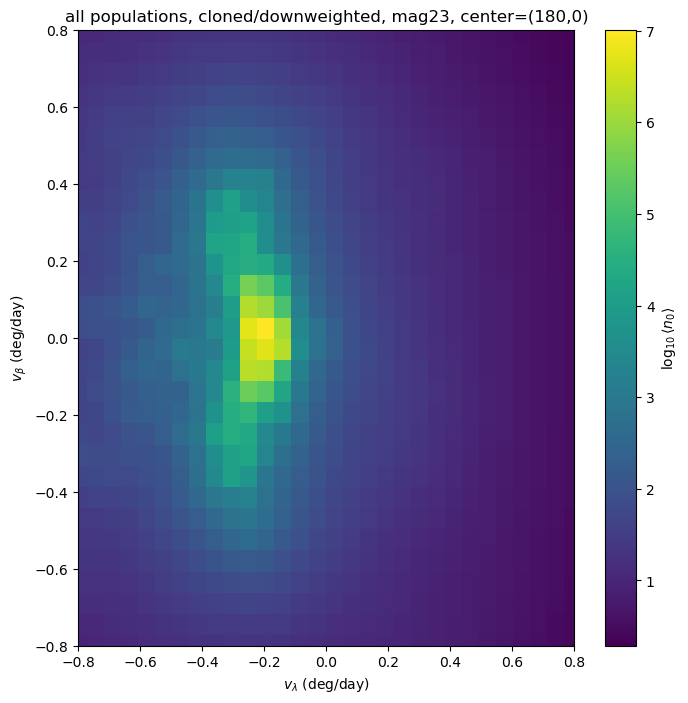

In [37]:
label = "mag23"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

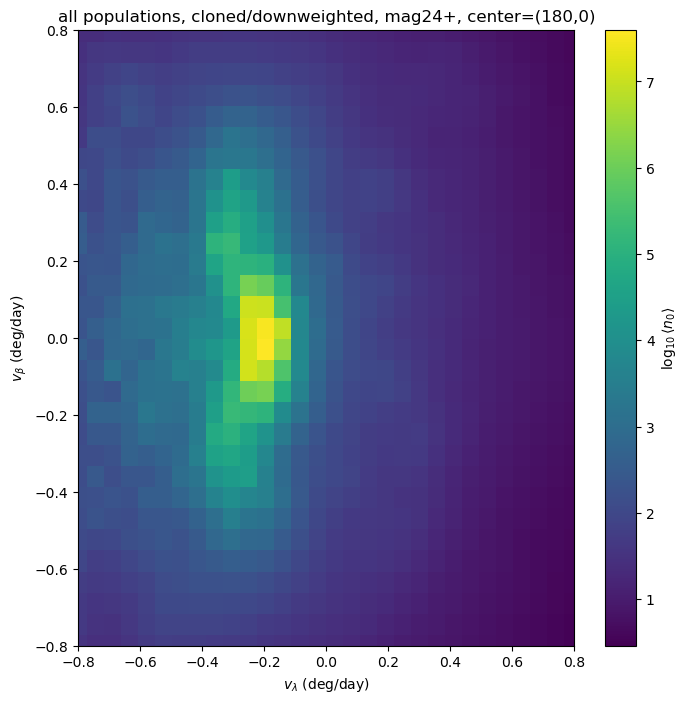

In [38]:
label = "mag24+"

log_map = np.log10(
    np.maximum(allpop_magbin_results[label]["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title(f"all populations, cloned/downweighted, {label}, center=(180,0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")
plt.show()

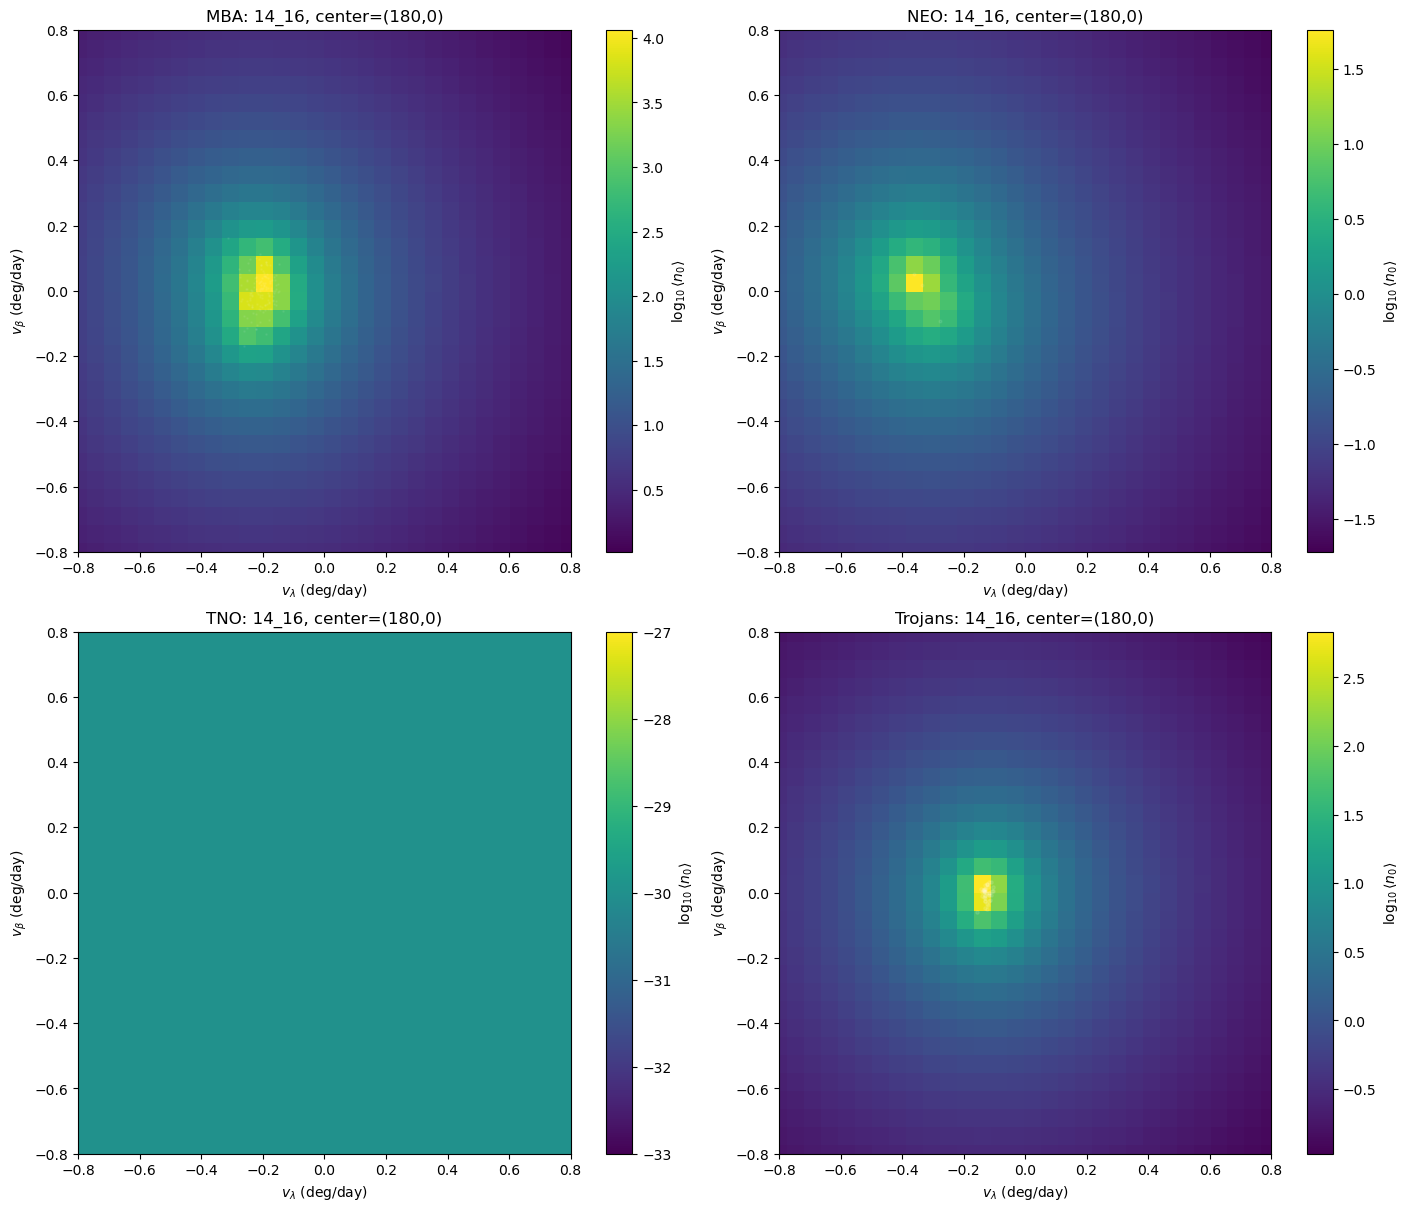

In [39]:
label = "14_16"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

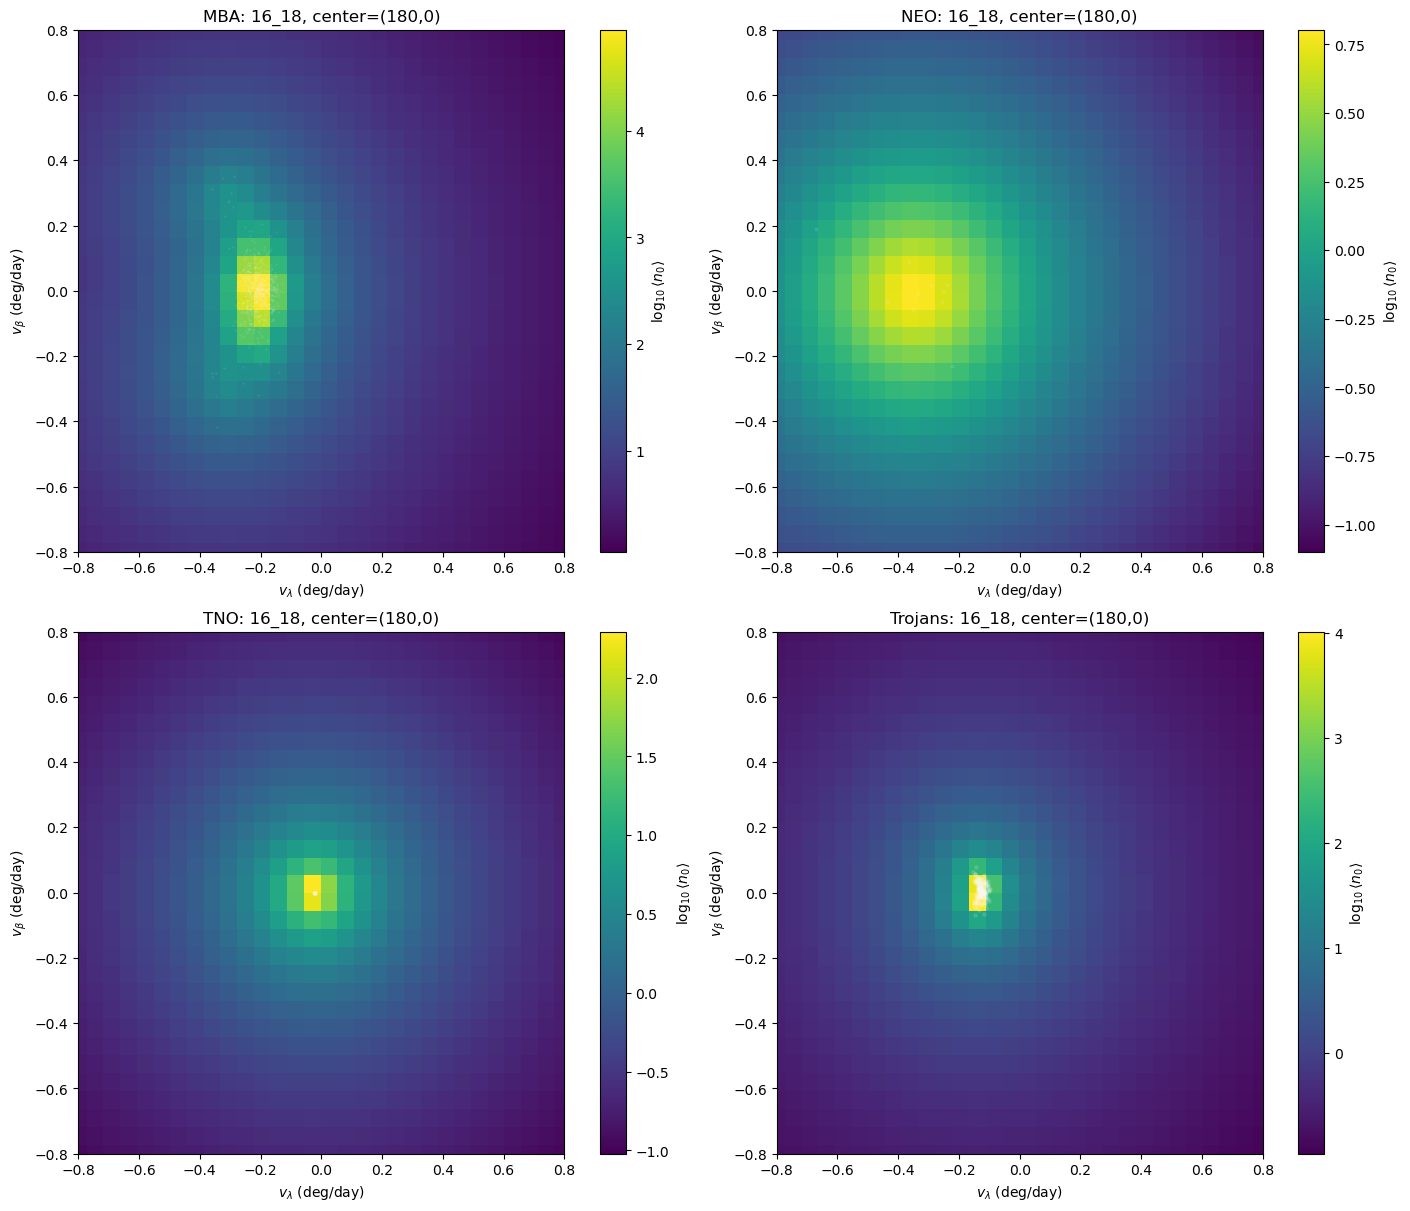

In [40]:
label = "16_18"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

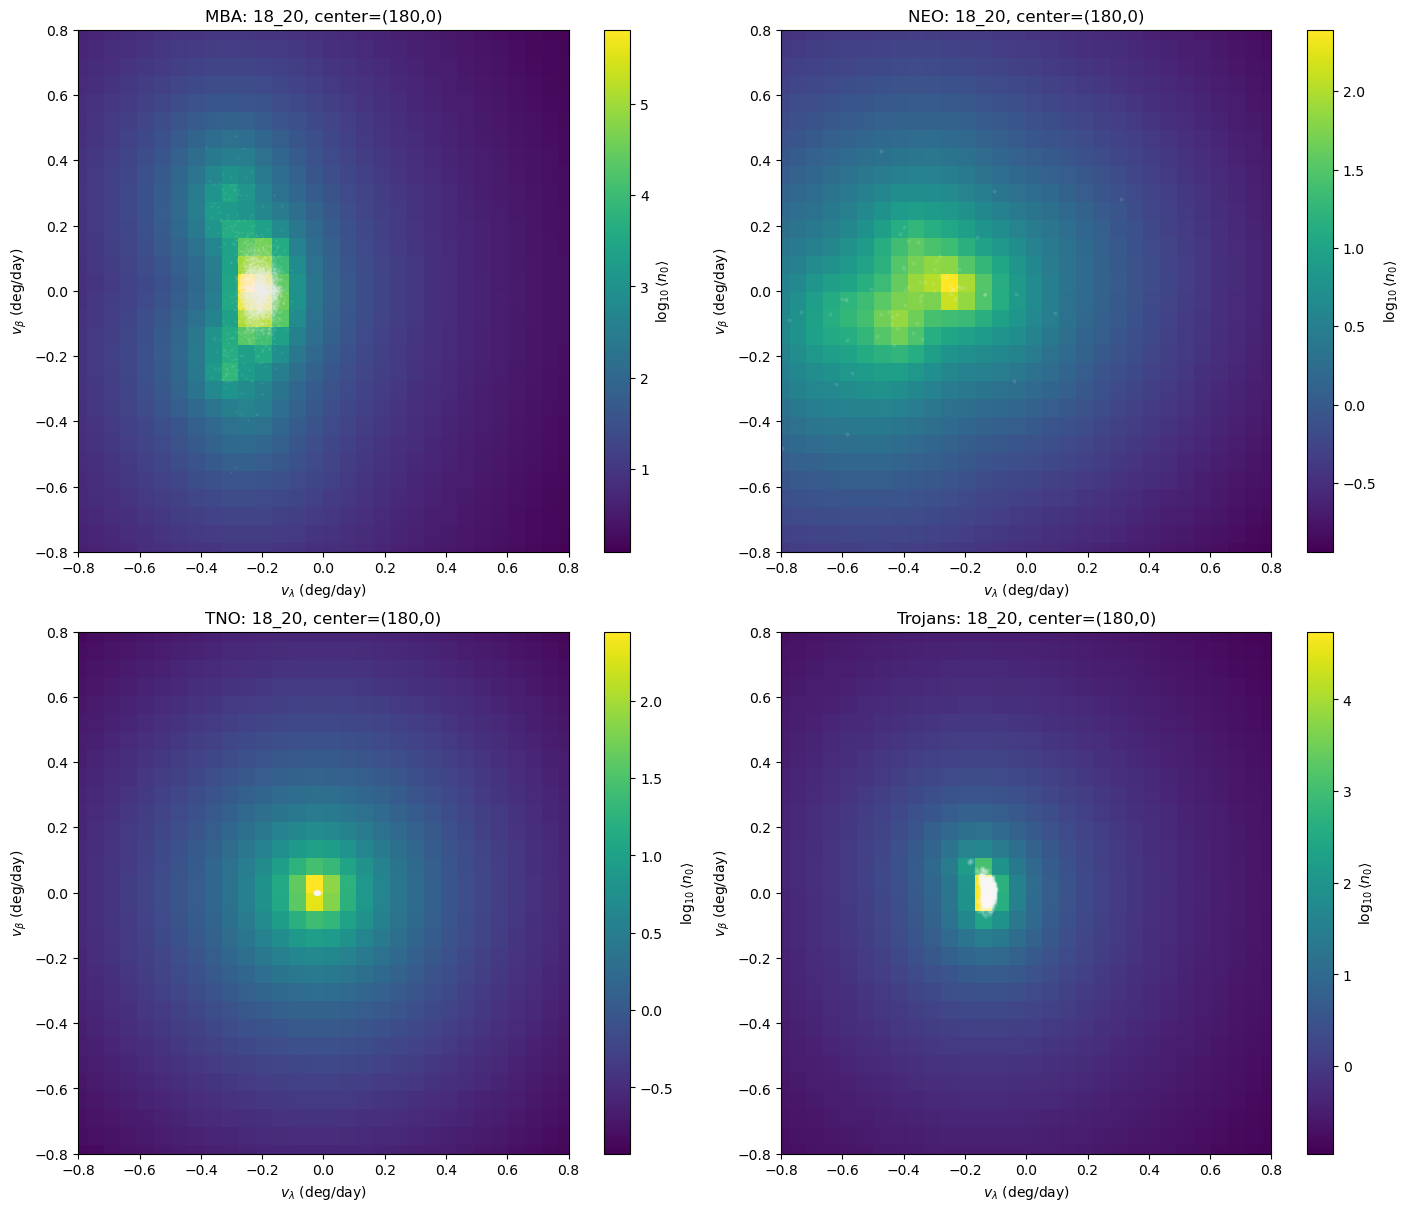

In [41]:
label = "18_20"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

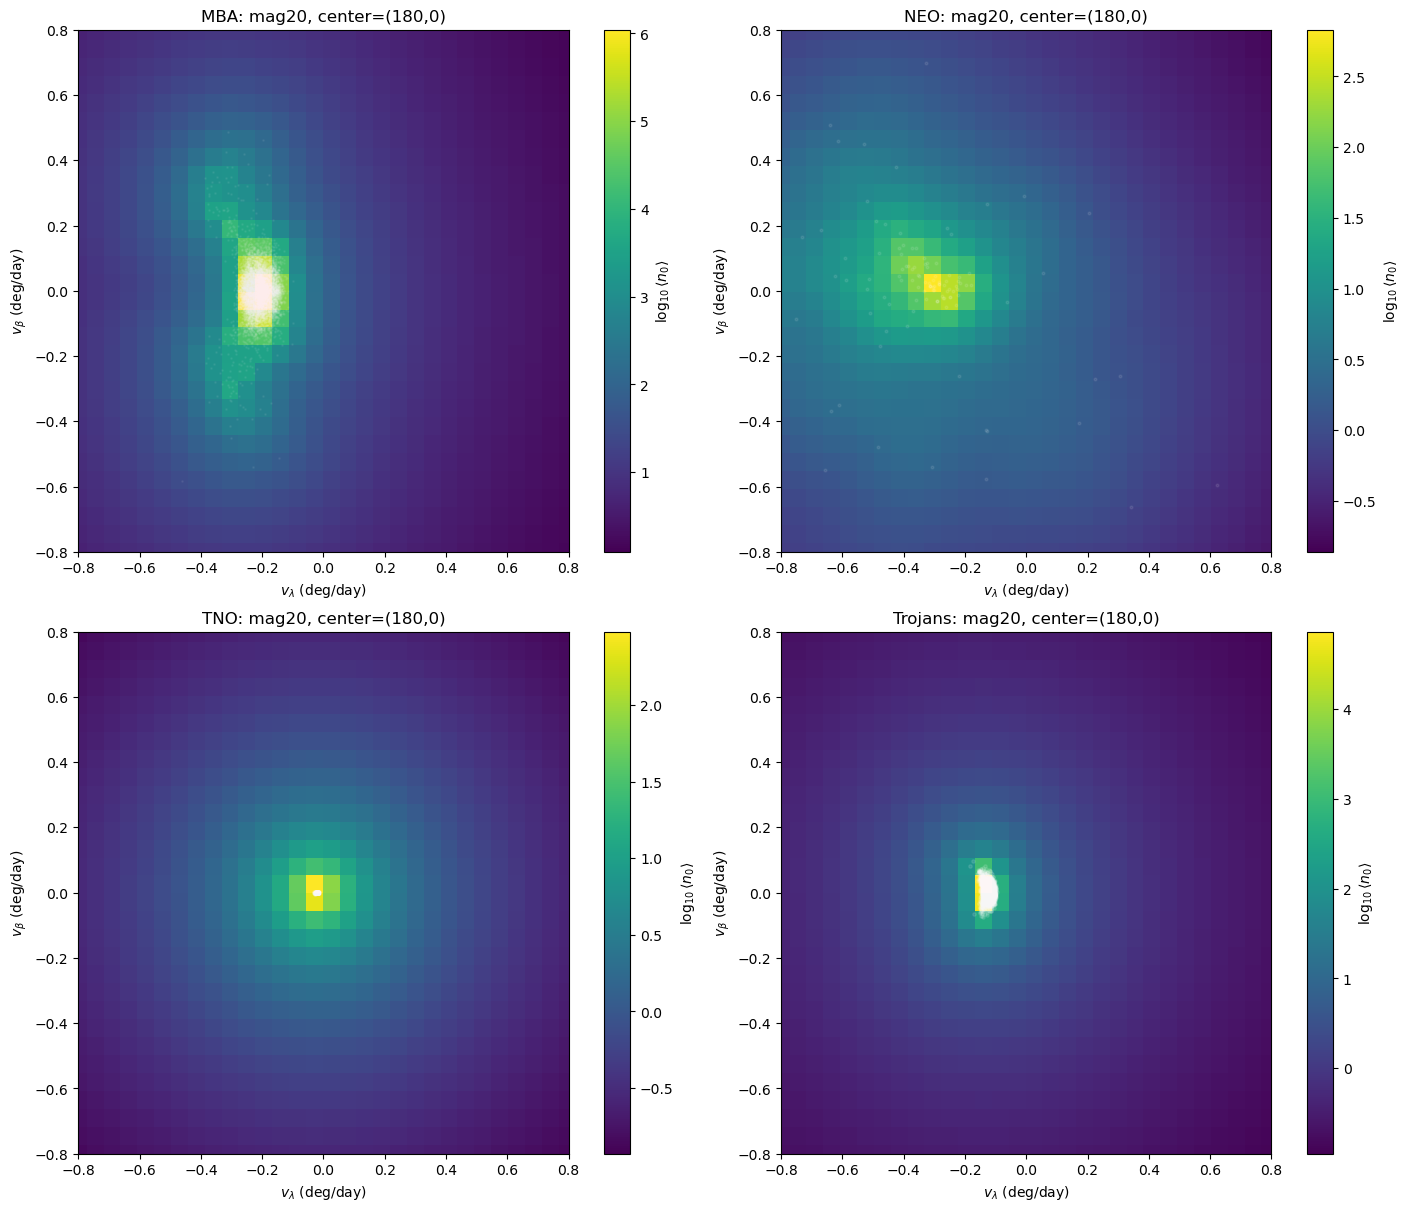

In [42]:
label = "mag20"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

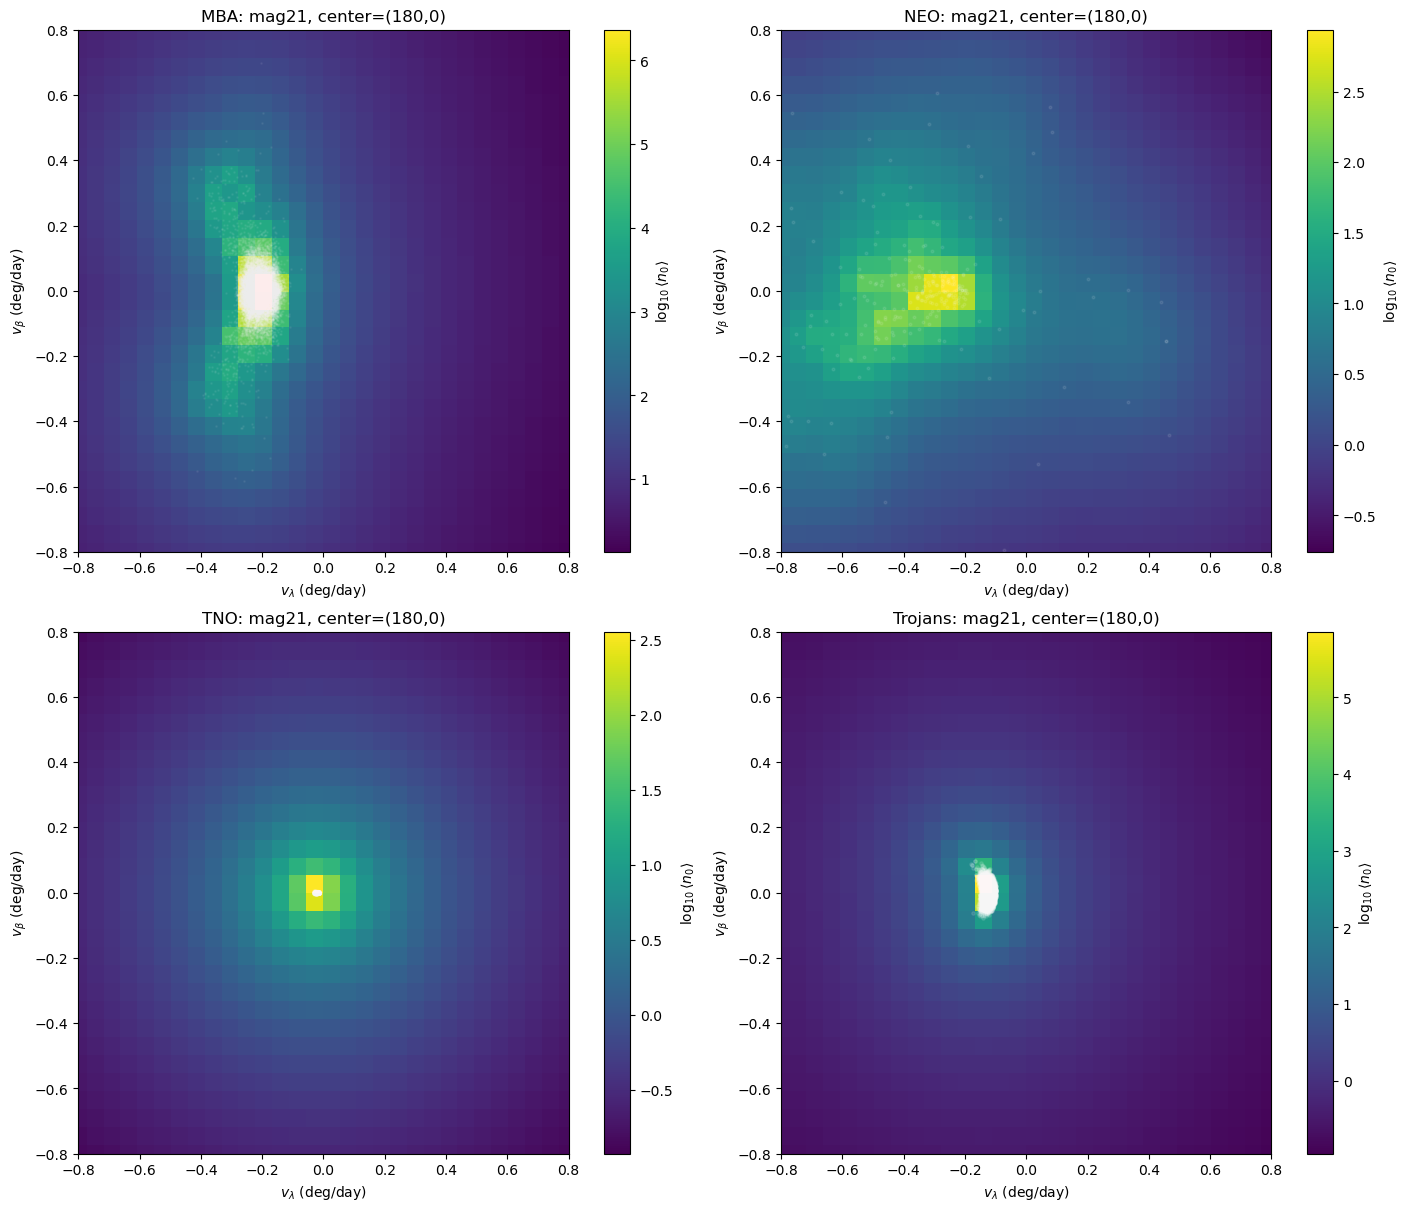

In [43]:
label = "mag21"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

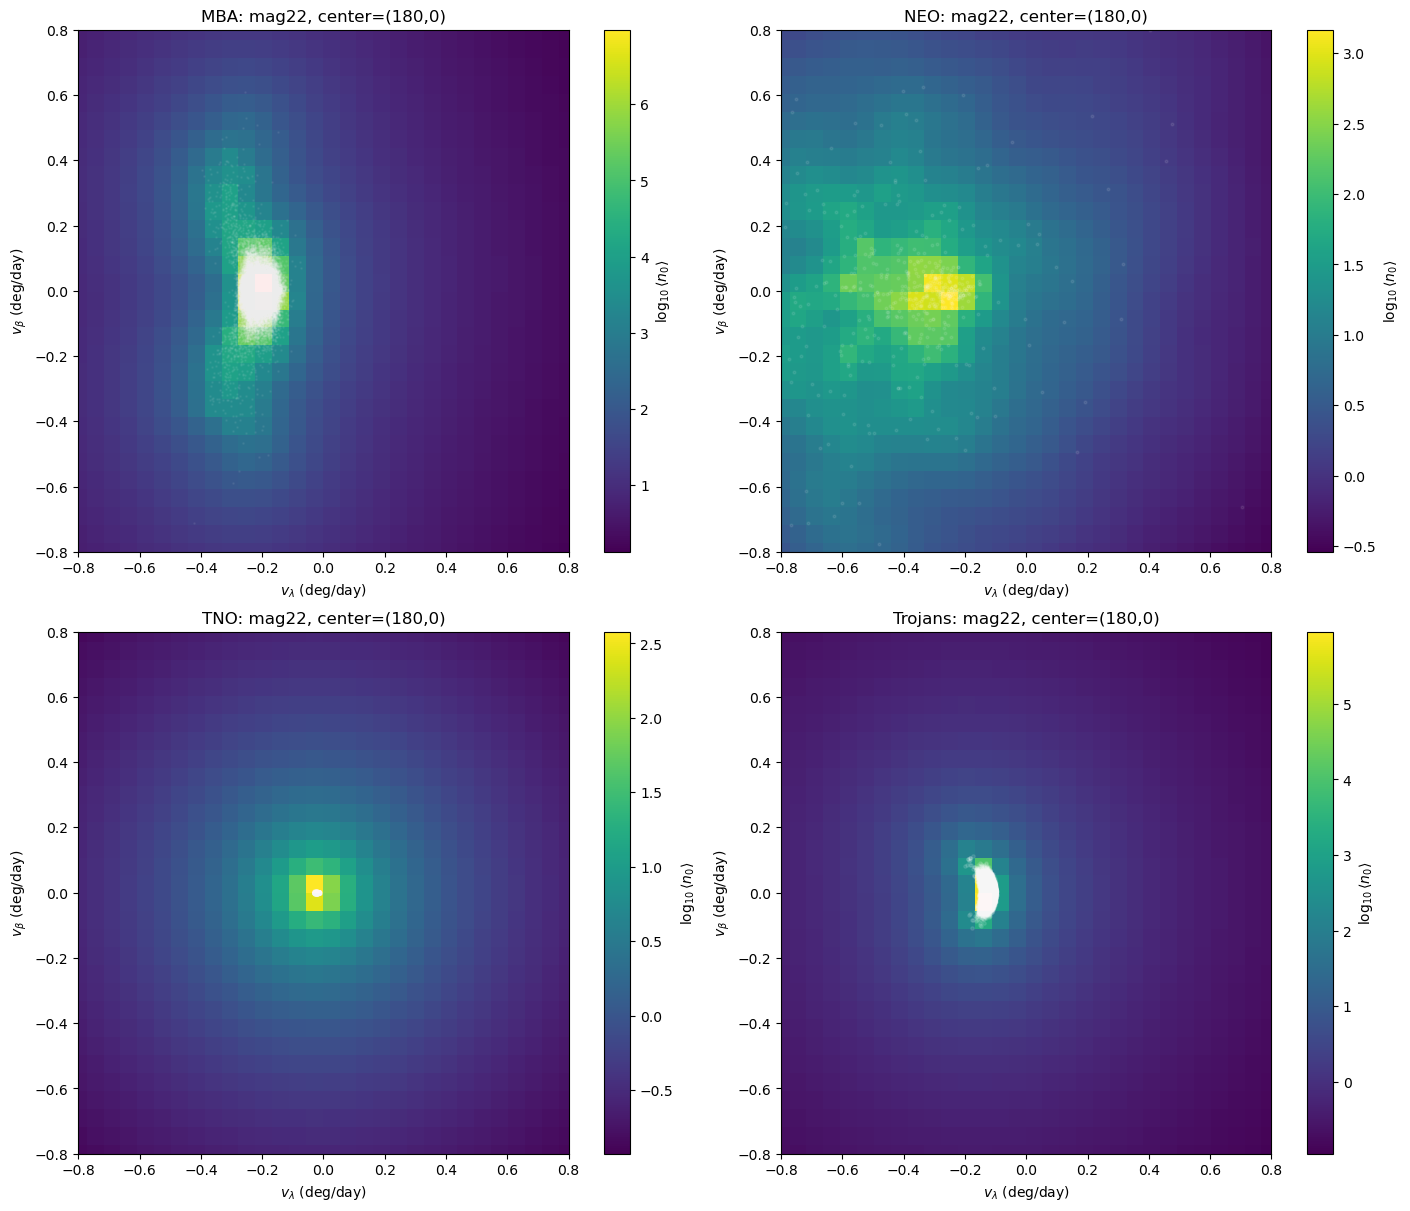

In [44]:
label = "mag22"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

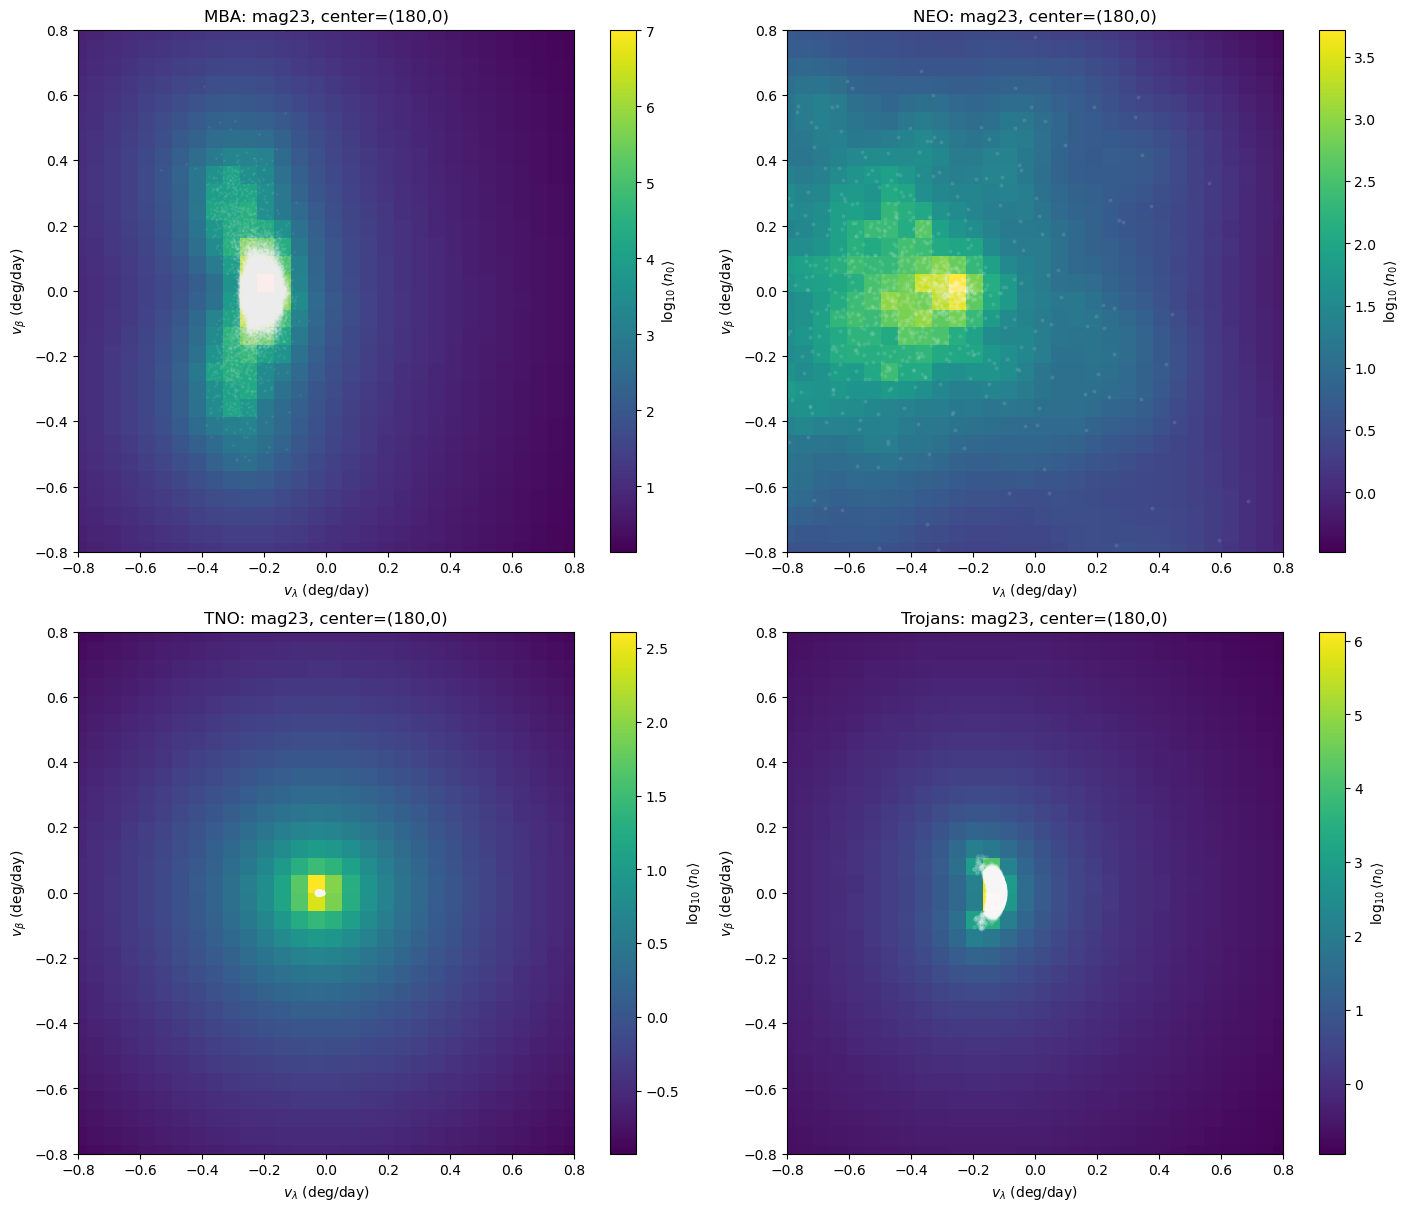

In [45]:
label = "mag23"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

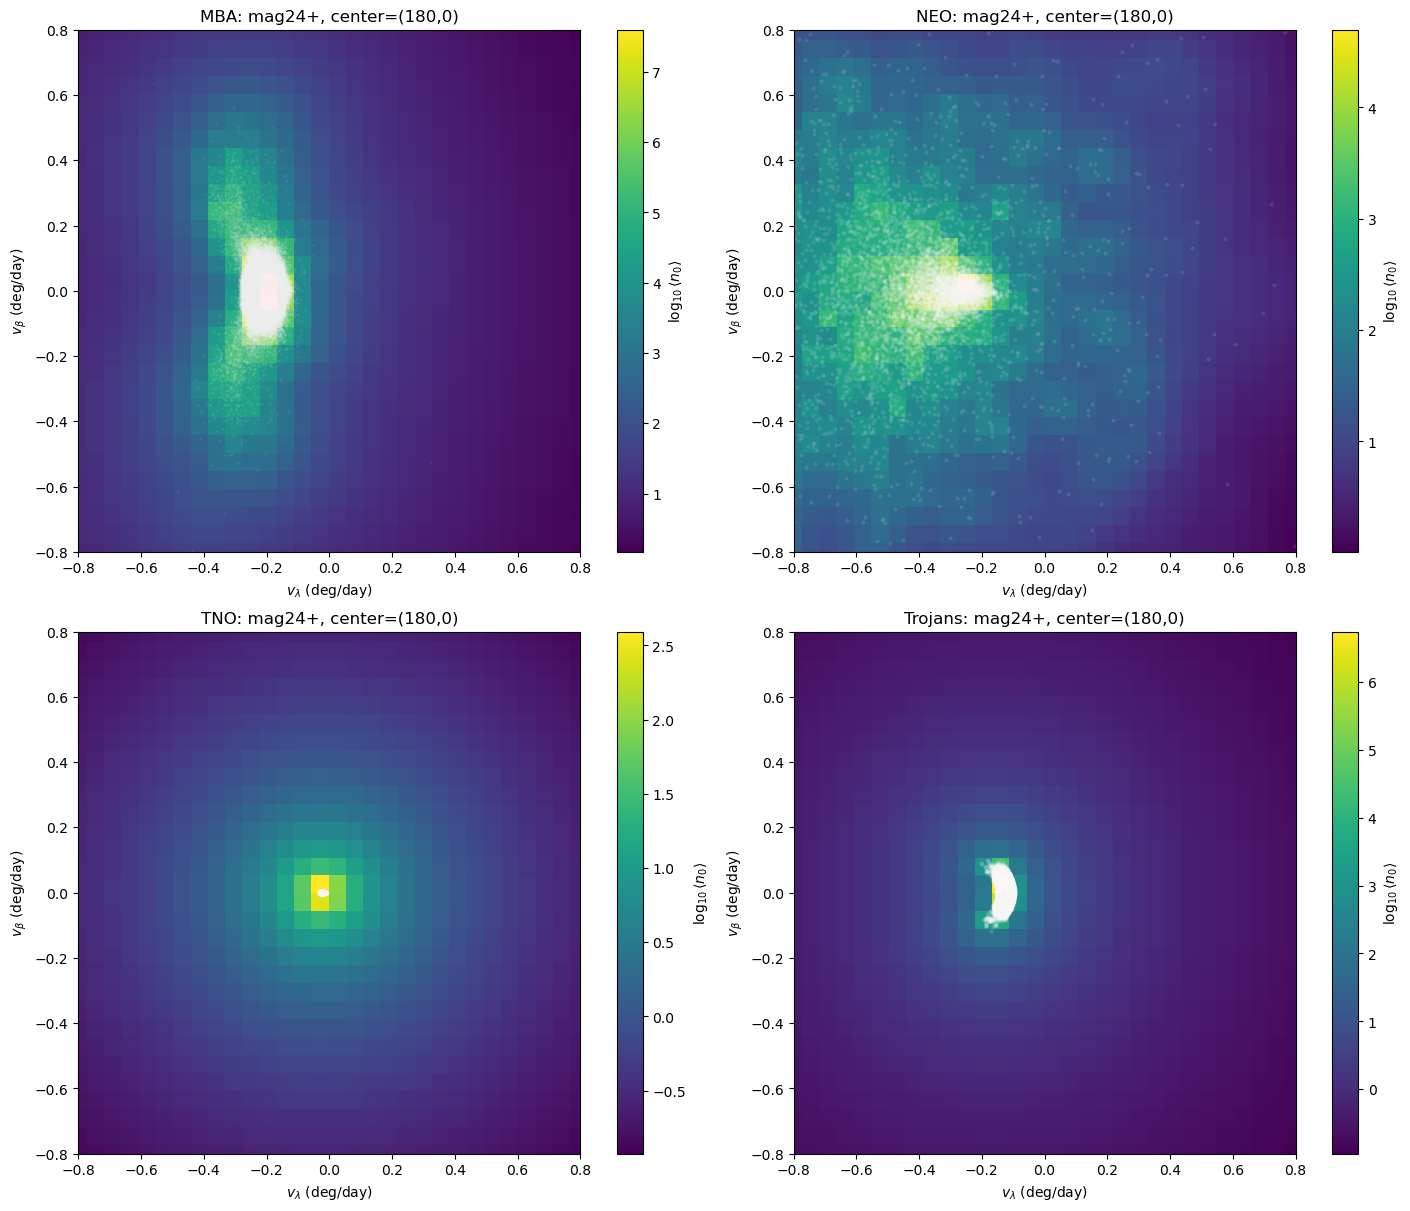

In [46]:
label = "mag24+"

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = allpop_magbin_results[label]["density_maps_downweighted"]
overlay_dict = allpop_magbin_results[label]["overlay"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))
    overlay = overlay_dict[pop_name]

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")
    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: {label}, center=(180,0)")
    fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()